In [1]:
import pandas as pd

DATA_DIR = "../data_raw"

train = pd.read_csv(f"{DATA_DIR}/train.csv")
features = pd.read_csv(f"{DATA_DIR}/features.csv")
stores = pd.read_csv(f"{DATA_DIR}/stores.csv")
test = pd.read_csv(f"{DATA_DIR}/test.csv")

print("Train shape:", train.shape)
print("Features shape:", features.shape)
print("Stores shape:", stores.shape)
print("Test shape:", test.shape)

print("\nTrain columns:", train.columns.tolist())
print("\nFeatures columns:", features.columns.tolist())
print("\nStores columns:", stores.columns.tolist())

Train shape: (421570, 5)
Features shape: (8190, 12)
Stores shape: (45, 3)
Test shape: (115064, 4)

Train columns: ['Store', 'Dept', 'Date', 'Weekly_Sales', 'IsHoliday']

Features columns: ['Store', 'Date', 'Temperature', 'Fuel_Price', 'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5', 'CPI', 'Unemployment', 'IsHoliday']

Stores columns: ['Store', 'Type', 'Size']


In [2]:
import pandas as pd
import numpy as np

# Parse dates
train["Date"] = pd.to_datetime(train["Date"])
features["Date"] = pd.to_datetime(features["Date"])
test["Date"] = pd.to_datetime(test["Date"])

# Merge train with features + stores
df = (
    train.merge(features, on=["Store", "Date"], how="left", suffixes=("_train", "_feat"))
         .merge(stores, on="Store", how="left")
)

print("Master df shape:", df.shape)
print("Missing in join (any feature columns missing):", df[["Temperature","Fuel_Price","CPI","Unemployment"]].isna().any(axis=1).mean())

# Holiday columns check
print(df[["IsHoliday_train","IsHoliday_feat"]].head())
print("Holiday mismatch rate:", (df["IsHoliday_train"] != df["IsHoliday_feat"]).mean())

Master df shape: (421570, 17)
Missing in join (any feature columns missing): 0.0
   IsHoliday_train  IsHoliday_feat
0            False           False
1             True            True
2            False           False
3            False           False
4            False           False
Holiday mismatch rate: 0.0


In [3]:
missing = (df.isna().mean().sort_values(ascending=False) * 100).round(2)
missing = missing[missing > 0]
display(missing)

MarkDown2    73.61
MarkDown4    67.98
MarkDown3    67.48
MarkDown1    64.26
MarkDown5    64.08
dtype: float64

In [4]:
md_cols = ["MarkDown1","MarkDown2","MarkDown3","MarkDown4","MarkDown5"]

df[md_cols] = df[md_cols].fillna(0)

In [5]:
df[md_cols].isna().sum()

MarkDown1    0
MarkDown2    0
MarkDown3    0
MarkDown4    0
MarkDown5    0
dtype: int64

In [6]:
print(df["Weekly_Sales"].describe())
print("Negative Weekly_Sales:", (df["Weekly_Sales"] < 0).sum())

count    421570.000000
mean      15981.258123
std       22711.183519
min       -4988.940000
25%        2079.650000
50%        7612.030000
75%       20205.852500
max      693099.360000
Name: Weekly_Sales, dtype: float64
Negative Weekly_Sales: 1285


In [7]:
df.groupby("IsHoliday_train")["Weekly_Sales"].agg(["count","mean","median"]).round(2)

,count,mean,median
IsHoliday_train,,,
False,391909,15901.45,7589.95
True,29661,17035.82,7947.74


In [8]:
# Sales by store
store_sales = df.groupby("Store")["Weekly_Sales"].agg(["mean","median","std"]).round(2)
display(store_sales.sort_values("mean", ascending=False).head())

# Sales by department
dept_sales = df.groupby("Dept")["Weekly_Sales"].agg(["mean","median","std"]).round(2)
display(dept_sales.sort_values("mean", ascending=False).head())

,mean,median,std
Store,,,
20,29508.30,16249.78,35661.53
4,29161.21,15116.81,34583.68
14,28784.85,15208.80,36911.12
13,27355.14,14018.46,33853.47
2,26898.07,14333.53,33077.61


,mean,median,std
Dept,,,
92,75204.87,61816.77,49413.73
95,69824.42,60774.39,38200.54
38,61090.62,57336.65,23966.91
72,50566.52,44312.36,44710.98
65,45441.71,47281.16,7086.89


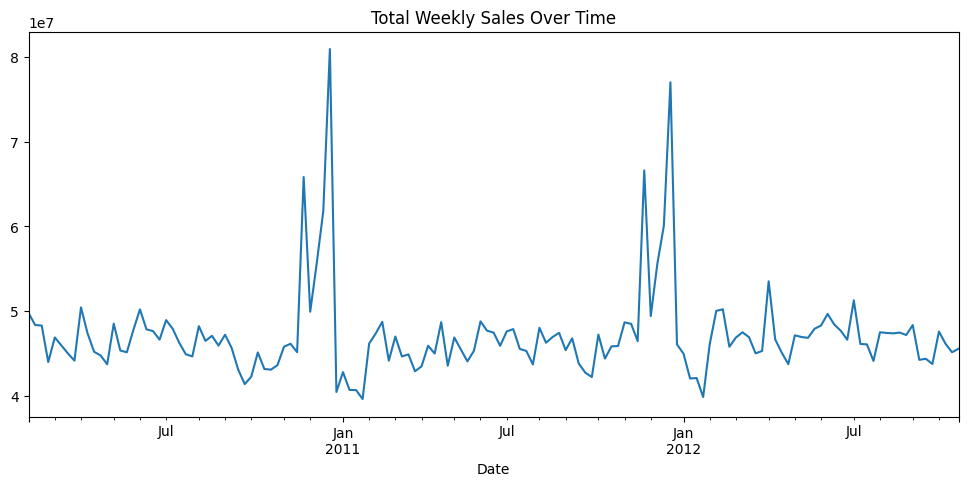

In [9]:
import matplotlib.pyplot as plt

# Total weekly sales over time
weekly_total = df.groupby("Date")["Weekly_Sales"].sum()

plt.figure(figsize=(12,5))
weekly_total.plot()
plt.title("Total Weekly Sales Over Time")
plt.show()

In [10]:
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values(["Store", "Dept", "Date"])

# 3. Time Feature Engineering

In [11]:
# Group by Store & Dept to avoid leakage
df["lag_1"] = df.groupby(["Store", "Dept"])["Weekly_Sales"].shift(1)
df["lag_4"] = df.groupby(["Store", "Dept"])["Weekly_Sales"].shift(4)
df["lag_52"] = df.groupby(["Store", "Dept"])["Weekly_Sales"].shift(52)

In [12]:
df["rolling_4_mean"] = (
    df.groupby(["Store", "Dept"])["Weekly_Sales"]
      .shift(1)
      .rolling(4)
      .mean()
)

df["rolling_12_mean"] = (
    df.groupby(["Store", "Dept"])["Weekly_Sales"]
      .shift(1)
      .rolling(12)
      .mean()
)

In [13]:
df.isna().sum().sort_values(ascending=False).head(10)

lag_52             160487
rolling_12_mean     38615
rolling_4_mean      13134
lag_4               13134
lag_1                3331
Store                   0
Temperature             0
IsHoliday_train         0
Weekly_Sales            0
Date                    0
dtype: int64

In [14]:
# Check date range
print(df["Date"].min(), df["Date"].max())

2010-02-05 00:00:00 2012-10-26 00:00:00


In [15]:
cutoff_date = "2012-05-01"

train_df = df[df["Date"] < cutoff_date]
valid_df = df[df["Date"] >= cutoff_date]

print("Train shape:", train_df.shape)
print("Valid shape:", valid_df.shape)

Train shape: (344667, 22)
Valid shape: (76903, 22)


In [16]:
target = "Weekly_Sales"

drop_cols = [
    "Weekly_Sales",
    "Date"
]

X_train = train_df.drop(columns=drop_cols)
y_train = train_df[target]

X_valid = valid_df.drop(columns=drop_cols)
y_valid = valid_df[target]

print("Features used:", X_train.columns.tolist())

Features used: ['Store', 'Dept', 'IsHoliday_train', 'Temperature', 'Fuel_Price', 'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5', 'CPI', 'Unemployment', 'IsHoliday_feat', 'Type', 'Size', 'lag_1', 'lag_4', 'lag_52', 'rolling_4_mean', 'rolling_12_mean']


In [18]:
X_train = X_train.drop(columns=["IsHoliday_feat"])
X_valid = X_valid.drop(columns=["IsHoliday_feat"])

In [19]:
X_train["Type"] = X_train["Type"].map({"A":0, "B":1, "C":2})
X_valid["Type"] = X_valid["Type"].map({"A":0, "B":1, "C":2})

In [20]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(
    X_train,
    y_train,
    eval_set=[(X_valid, y_valid)],
    verbose=False
)

preds = model.predict(X_valid)

mae = mean_absolute_error(y_valid, preds)
rmse = np.sqrt(mean_squared_error(y_valid, preds))

print("Validation MAE:", mae)
print("Validation RMSE:", rmse)

Validation MAE: 1422.6372743479
Validation RMSE: 2872.2684669605883


In [21]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Naive baseline: predict this week's sales as last week's sales
baseline_preds = X_valid["lag_1"]

# If any NaNs exist in lag_1, drop those rows for a fair comparison
mask = baseline_preds.notna()
baseline_mae = mean_absolute_error(y_valid[mask], baseline_preds[mask])
baseline_rmse = np.sqrt(mean_squared_error(y_valid[mask], baseline_preds[mask]))

print("Baseline MAE (lag_1):", baseline_mae)
print("Baseline RMSE (lag_1):", baseline_rmse)

Baseline MAE (lag_1): 1547.2174573713987
Baseline RMSE (lag_1): 3442.3716385029193


In [23]:
import os
import joblib

# Create models directory if it doesn't exist
os.makedirs("models", exist_ok=True)

# Save model
joblib.dump(model, "models/xgb_model.pkl")

['models/xgb_model.pkl']

In [24]:
import os
os.makedirs("reports", exist_ok=True)

In [25]:
import os
print(os.getcwd())

C:\Users\akwin\My Drive\Data Science\Projects\retail-price-inventory-optimization\notebooks
